# Proyecto Implementacion fase 1
- Javier Prado 21486
- Bryan España 21550

## Dataset a utilizar
El dataset a utilizar es sacado de:
https://www.kaggle.com/datasets/chethuhn/network-intrusion-dataset
Este es el conjunto de datos de evaluación de detección de intrusiones (CIC-IDS2017). 

## Construcción del dataset (CIC-IDS2017)

El dataset CIC-IDS2017 fue construido por el Canadian Institute for Cybersecurity (CIC) con el objetivo de crear un conjunto de datos realista y actualizado para la evaluación de sistemas de detección de intrusiones (IDS). A diferencia de datasets antiguos, este fue diseñado para simular el comportamiento real de una red empresarial bajo condiciones normales y bajo ataque.

## Cómo fue construido

El dataset se generó en un entorno controlado de red durante un período de aproximadamente 5 días (lunes a viernes), donde se simuló el tráfico de una organización real. Durante este proceso:

Se configuró una infraestructura con múltiples máquinas (atacantes y víctimas) que representaban una red empresarial real.
Se generó tráfico normal (benigno) utilizando perfiles de comportamiento de usuarios reales, simulando actividades como navegación web, envío de correos, uso de FTP y SSH.
A partir del segundo día, se ejecutaron distintos tipos de ataques controlados en la red, incluyendo:
Ataques de fuerza bruta (FTP y SSH)
Ataques DoS y DDoS
Escaneo de puertos
Ataques web (SQL Injection, XSS)
Botnets e infiltraciones
Heartbleed

Todo el tráfico de red fue capturado en formato PCAP (packet capture), lo que representa los paquetes reales transmitidos en la red.

## Procesamiento de los datos

Posteriormente, los datos capturados fueron procesados utilizando una herramienta llamada CICFlowMeter, que transforma el tráfico de red en flujos (flows).

Un flow representa una comunicación entre dos dispositivos (IP origen y destino), y de cada flujo se extraen múltiples características como:

Número de paquetes
Duración del flujo
Tamaño de paquetes
Flags TCP
Estadísticas (media, desviación estándar, etc.)

Esto permitió generar alrededor de 80 características por flujo.

Características del conjunto de datos

![Descripción](imagen.png)

## Labels

Cada flujo fue etiquetado como:

Benigno (normal)
Ataque (con tipo específico)

En total, el dataset contiene múltiples clases de ataque además de la clase normal, lo que lo hace ideal para problemas de clasificación supervisada en Machine Learning.

# Analisis exploratorio

In [1]:
# Para descargar el dataset se debe descargar con el siguiente codigo
# se mantendra comentada esta seccion para evitar descargar el dataset cada vez que se ejecute el codigo

# al ejecutarlo se creara una carpeta en la carpeta del repo, dentro de esta carpeta se descargara el dataset
from pathlib import Path
import kagglehub
import shutil

# 📁 Ruta base (donde está el notebook)
BASE_DIR = Path().resolve()

# 📁 Carpeta dataset dentro del proyecto
DATASET_DIR = BASE_DIR / "dataset"
DATASET_HANDLE = "chethuhn/network-intrusion-dataset"

# Crear carpeta si no existe
DATASET_DIR.mkdir(parents=True, exist_ok=True)

# Evitar descargar si ya existe contenido
if any(DATASET_DIR.iterdir()):
    print("⚡ Dataset ya existe en:", DATASET_DIR)
else:
    print("📥 Descargando dataset...")

    # Descargar dataset con el identificador completo de Kaggle
    download_path = Path(kagglehub.dataset_download(DATASET_HANDLE))

    # Copiar archivos desde la caché de Kaggle al proyecto
    for source in download_path.iterdir():
        destination = DATASET_DIR / source.name
        if source.is_dir():
            shutil.copytree(source, destination, dirs_exist_ok=True)
        else:
            shutil.copy2(source, destination)

    print("✅ Dataset descargado en:", DATASET_DIR)

⚡ Dataset ya existe en: C:\Users\javil\OneDrive\Documentos\U\Data Science\Intrusion_Detection_System\dataset


C:\Users\javil\OneDrive\Documentos\U\Data Science\Intrusion_Detection_System\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Analisis exploratorio detallado

Este bloque construye un EDA orientado a describir el dataset **CIC-IDS2017** desde cuatro angulos:

- estructura general del conjunto de datos
- distribucion de clases y archivos
- calidad de datos y variables redundantes
- caracteristicas clave mas informativas para distinguir trafico benigno y ataques


Construyendo vista general del dataset...


Evaluando calidad de datos...


Generando muestra balanceada para visualizacion y ranking de variables...


## 1. Vista general del dataset

,metric,value
0,Archivos CSV,8
1,Registros totales,2830743
2,Caracteristicas numericas y de red,78
3,Clases de trafico,15


,file,rows,classes,benign_pct,attack_pct,dominant_attack,dominant_attack_rows
0,Wednesday-workingHours.pcap_ISCX.csv,692703,6,63.52,36.48,DoS Hulk,231073
1,Monday-WorkingHours.pcap_ISCX.csv,529918,1,100.00,0.00,None,0
2,Tuesday-WorkingHours.pcap_ISCX.csv,445909,3,96.90,3.10,FTP-Patator,7938
3,Thursday-WorkingHours-Afternoon-Infilteration....,288602,2,99.99,0.01,Infiltration,36
4,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...,286467,2,44.52,55.48,PortScan,158930
5,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,225745,2,43.29,56.71,DDoS,128027
6,Friday-WorkingHours-Morning.pcap_ISCX.csv,191033,2,98.97,1.03,Bot,1966
7,Thursday-WorkingHours-Morning-WebAttacks.pcap_...,170366,4,98.72,1.28,Web Attack - Brute Force,1507


,label,count,pct
0,BENIGN,2273097,80.3004
1,DoS Hulk,231073,8.1630
2,PortScan,158930,5.6144
3,DDoS,128027,4.5227
4,DoS GoldenEye,10293,0.3636
5,FTP-Patator,7938,0.2804
6,SSH-Patator,5897,0.2083
7,DoS slowloris,5796,0.2048
8,DoS Slowhttptest,5499,0.1943
9,Bot,1966,0.0695


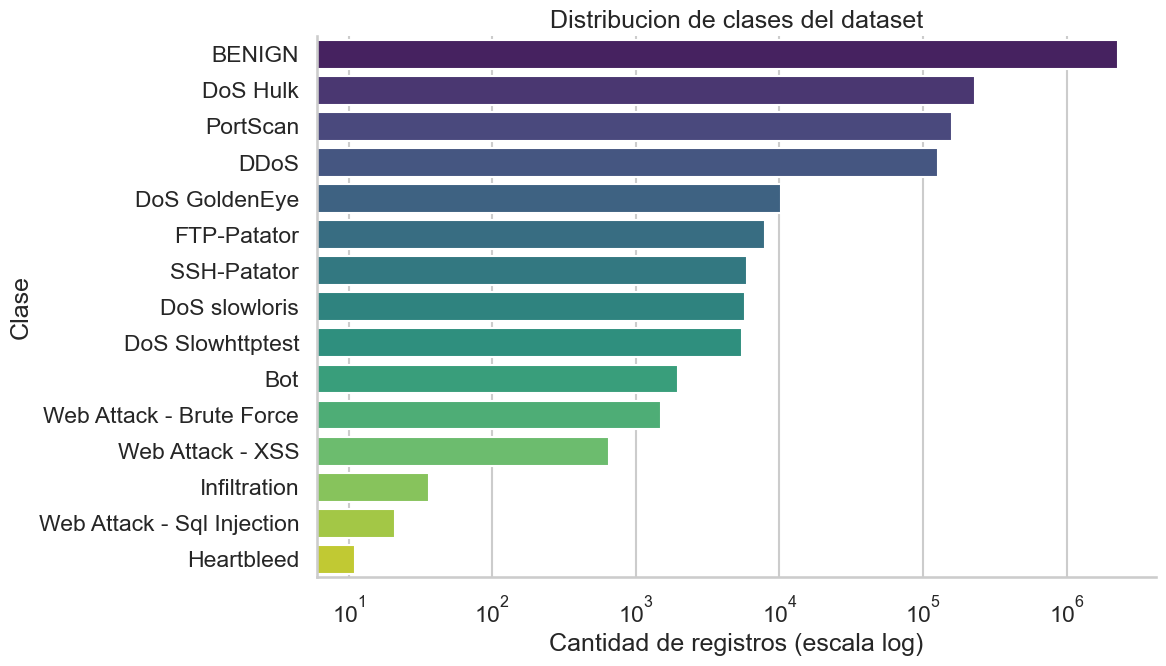

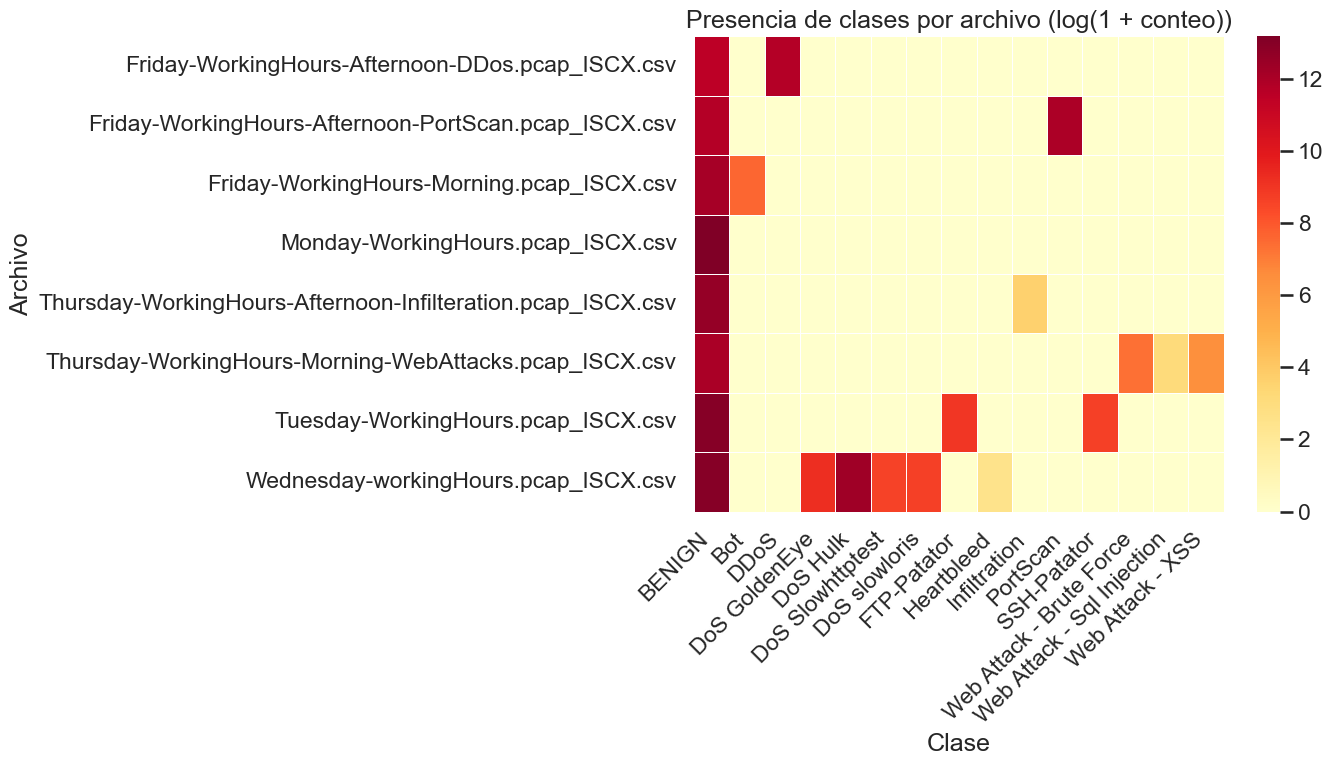

## 2. Calidad de datos y variables redundantes

,feature,missing_values,infinite_values
0,Flow Packets/s,0,2867
1,Flow Bytes/s,1358,1509


,file,duplicate_rows,duplicate_pct
0,Wednesday-workingHours.pcap_ISCX.csv,81909,11.82
1,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...,72353,25.26
2,Thursday-WorkingHours-Afternoon-Infilteration....,35630,12.35
3,Monday-WorkingHours.pcap_ISCX.csv,26935,5.08
4,Tuesday-WorkingHours.pcap_ISCX.csv,24065,5.40
5,Friday-WorkingHours-Morning.pcap_ISCX.csv,6888,3.61
6,Thursday-WorkingHours-Morning-WebAttacks.pcap_...,6066,3.56
7,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,2633,1.17


,constant_feature
0,Bwd PSH Flags
1,Bwd URG Flags
2,Fwd Avg Bytes/Bulk
3,Fwd Avg Packets/Bulk
4,Fwd Avg Bulk Rate
5,Bwd Avg Bytes/Bulk
6,Bwd Avg Packets/Bulk
7,Bwd Avg Bulk Rate


,feature_a,feature_b
0,Total Fwd Packets,Subflow Fwd Packets
1,Total Backward Packets,Subflow Bwd Packets
2,Fwd Header Length,Fwd Header Length.1


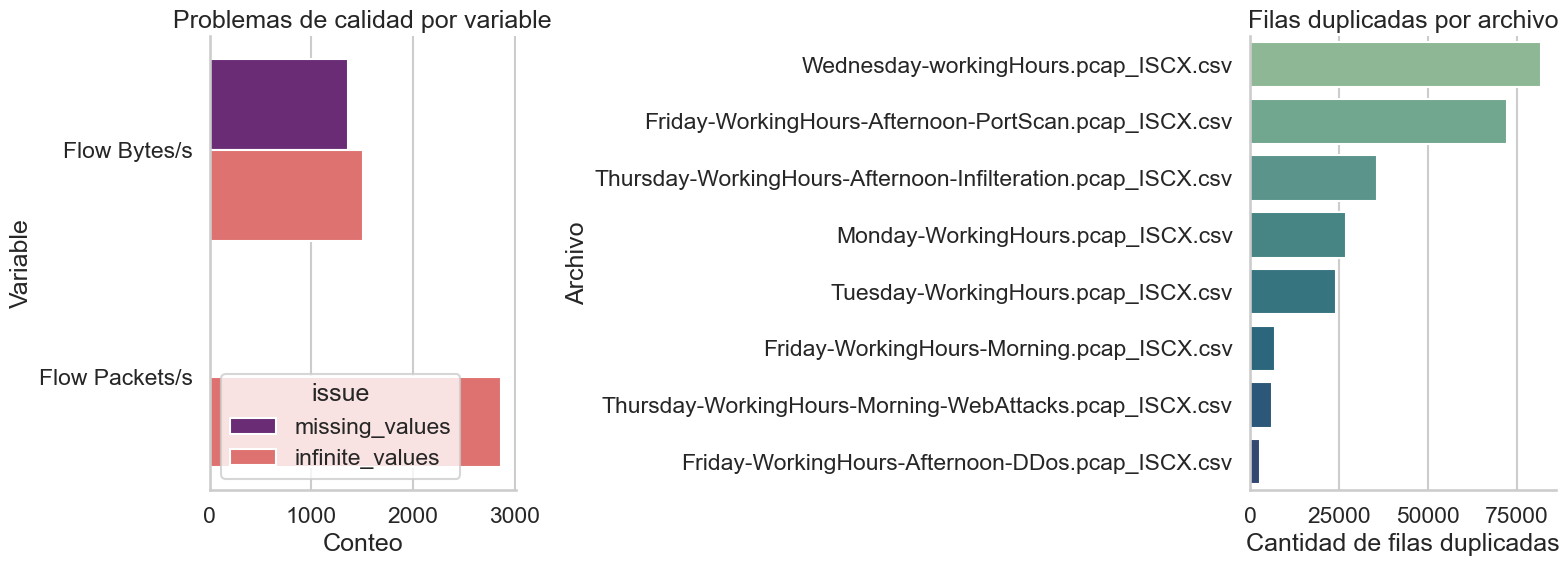

## 3. Caracteristicas clave del trafico

,feature,category,description,security_value,mutual_info,attack_vs_benign_shift
0,Fwd Header Length,Cabeceras y control,Longitud acumulada de cabeceras en direccion f...,Suele correlacionar con la cantidad y tipo de ...,1.7102,0.0185
1,Average Packet Size,Tamano de paquetes,Promedio general de bytes por paquete del flujo.,Resume el perfil de tamano de la sesion y suel...,1.6943,0.1550
2,Packet Length Mean,Tamano de paquetes,Tamano promedio de los paquetes observados en ...,Los ataques automatizados suelen mostrar perfi...,1.6939,0.1379
3,Flow IAT Max,Temporalidad,Mayor tiempo entre llegadas dentro del flujo.,Ayuda a encontrar flujos con pausas largas o c...,1.6559,0.0822
4,Flow Duration,Temporalidad,Duracion total del flujo desde el primer hasta...,"Separa ataques muy breves y repetitivos, como ...",1.6454,0.1449
5,Flow IAT Mean,Temporalidad,Promedio del tiempo entre llegadas sucesivas d...,Distingue patrones regulares de automatizacion...,1.6323,0.0369
6,Flow Packets/s,Volumen,Tasa de paquetes por segundo del flujo.,"Es especialmente util para evidenciar DDoS, Do...",1.6316,0.0005
7,Fwd IAT Max,Temporalidad,Maximo tiempo entre llegadas en direccion forw...,"Resalta pausas largas del emisor, utiles para ...",1.6136,0.0802
8,Fwd Packets/s,Volumen,Paquetes por segundo emitidos en direccion for...,Es util para reconocer rafagas del cliente dur...,1.6119,0.0003
9,Fwd IAT Mean,Temporalidad,Promedio del tiempo entre llegadas en direccio...,Permite comparar la cadencia con la que el ori...,1.5873,0.0389


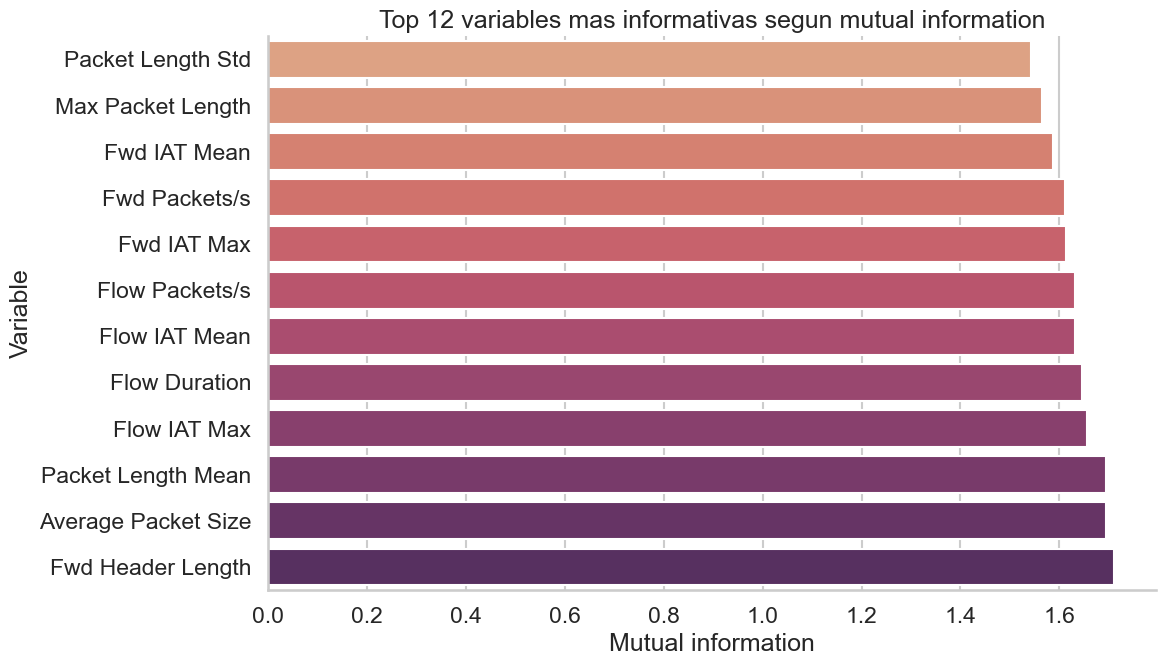

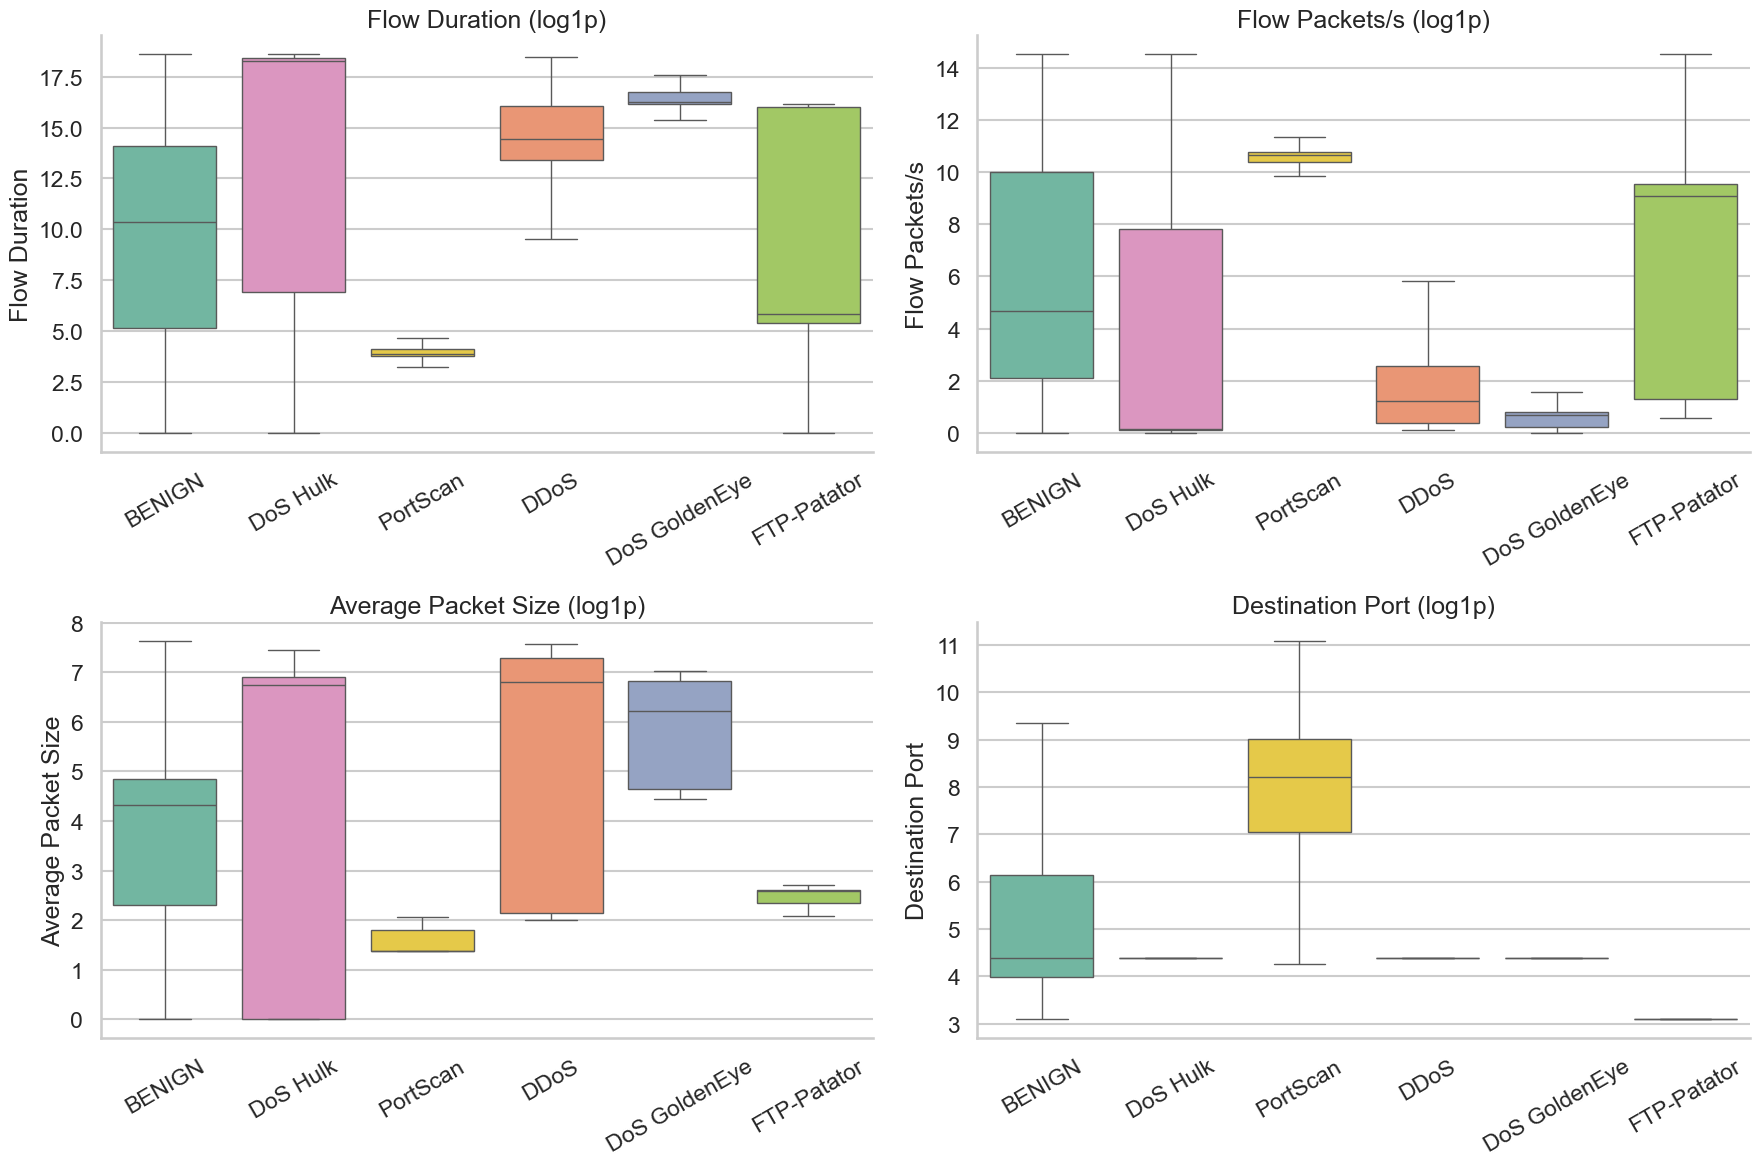

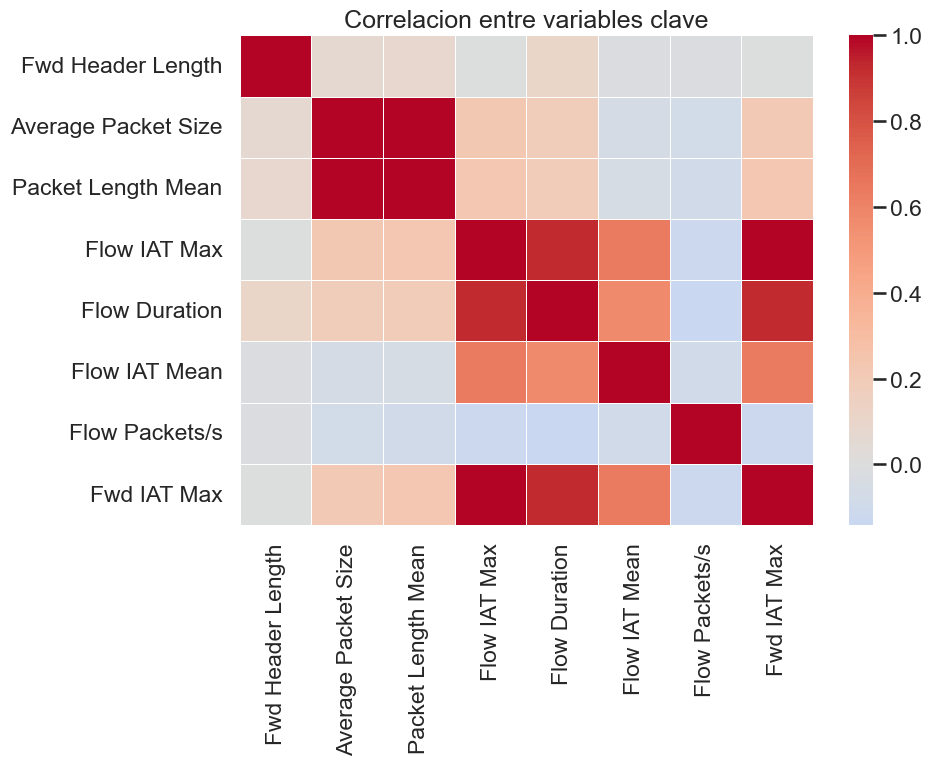

### Hallazgos principales
- El conjunto contiene **2,830,743 registros**, **78 variables** y **15 clases** distribuidas en **8 archivos** diarios.
- Existe un **desbalance fuerte de clases**: las mas frecuentes son BENIGN (80.30%), DoS Hulk (8.16%), PortScan (5.61%), DDoS (4.52%). Esto implica que metricas de accuracy por si solas serian enganiosas en etapas de modelado.
- La estructura temporal del dataset es muy util para el contexto: **Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv** es el archivo con mayor proporcion de ataques (56.71%), mientras que **Wednesday-workingHours.pcap_ISCX.csv** concentra la mayor diversidad de clases (6 clases).
- Los principales problemas de calidad estan concentrados en **Flow Packets/s, Flow Bytes/s**, con infinitos generados por divisiones sobre tasas, ademas de **256,479 filas duplicadas** dentro de archivos.
- Se detectaron **8 columnas constantes** y **3 pares de columnas redundantes exactas**, por lo que conviene excluirlas antes de entrenar modelos.
- Las variables con mas señal combinan **Cabeceras y control, Tamano de paquetes, Temporalidad, Volumen**. En especial destacan medidas de duracion, tasas por segundo, tamanos de paquete y longitud de cabeceras en direccion forward.
- Para la narrativa del informe, una buena idea es explicar las variables clave por familias: **volumen**, **temporalidad**, **tamano de paquetes**, **simetria del flujo** y **banderas TCP**.

In [2]:
from cicids_eda import run_eda

artifacts = run_eda(DATASET_DIR)


In [3]:
# Tabla de caracteristicas clave para el reporte
feature_report = (
    artifacts["key_features"][["feature", "category", "description", "security_value", "mutual_info", "attack_vs_benign_shift"]]
    .rename(columns={
        "feature": "Caracteristica",
        "category": "Categoria",
        "description": "Descripcion",
        "security_value": "Valor para IDS",
        "mutual_info": "Mutual information",
        "attack_vs_benign_shift": "Cambio ataque vs benigno",
    })
)

feature_report


,Caracteristica,Categoria,Descripcion,Valor para IDS,Mutual information,Cambio ataque vs benigno
0,Fwd Header Length,Cabeceras y control,Longitud acumulada de cabeceras en direccion f...,Suele correlacionar con la cantidad y tipo de ...,1.7102,0.0185
1,Average Packet Size,Tamano de paquetes,Promedio general de bytes por paquete del flujo.,Resume el perfil de tamano de la sesion y suel...,1.6943,0.1550
2,Packet Length Mean,Tamano de paquetes,Tamano promedio de los paquetes observados en ...,Los ataques automatizados suelen mostrar perfi...,1.6939,0.1379
3,Flow IAT Max,Temporalidad,Mayor tiempo entre llegadas dentro del flujo.,Ayuda a encontrar flujos con pausas largas o c...,1.6559,0.0822
4,Flow Duration,Temporalidad,Duracion total del flujo desde el primer hasta...,"Separa ataques muy breves y repetitivos, como ...",1.6454,0.1449
5,Flow IAT Mean,Temporalidad,Promedio del tiempo entre llegadas sucesivas d...,Distingue patrones regulares de automatizacion...,1.6323,0.0369
6,Flow Packets/s,Volumen,Tasa de paquetes por segundo del flujo.,"Es especialmente util para evidenciar DDoS, Do...",1.6316,0.0005
7,Fwd IAT Max,Temporalidad,Maximo tiempo entre llegadas en direccion forw...,"Resalta pausas largas del emisor, utiles para ...",1.6136,0.0802
8,Fwd Packets/s,Volumen,Paquetes por segundo emitidos en direccion for...,Es util para reconocer rafagas del cliente dur...,1.6119,0.0003
9,Fwd IAT Mean,Temporalidad,Promedio del tiempo entre llegadas en direccio...,Permite comparar la cadencia con la que el ori...,1.5873,0.0389



## Resumen interpretativo del EDA

**Contexto del dataset.** Segun la documentacion oficial del CIC, el trafico fue capturado entre el **3 y el 7 de julio de 2017**. El **lunes** contiene solo trafico benigno y entre **martes y viernes** se introducen ataques de fuerza bruta, DoS/DDoS, web attacks, botnet, infiltration, heartbleed y port scanning.

**Hallazgos principales sobre tu copia del dataset descargada desde Kaggle.**
- El conjunto analizado contiene **2,830,743 registros**, **78 variables** y **15 clases**.
- Existe **desbalance de clases**: `BENIGN` representa **80.30%** del total. Las familias de ataque mas frecuentes son **DoS Hulk (8.16%), PortScan (5.61%), DDoS (4.52%)**.
- Las clases extremadamente raras son **Infiltration, Web Attack - Sql Injection, Heartbleed**, por lo que conviene tratarlas con cuidado al graficar o entrenar modelos.
- Las variables con mas poder descriptivo se concentran en **duracion del flujo**, **tasas por segundo**, **tiempos entre llegadas**, **tamano de paquetes** y **longitud de cabeceras**.
- En calidad de datos se observan **Flow Packets/s: 2867 infinitos, Flow Bytes/s: 1358 nulos; 1509 infinitos** y **256,479 filas duplicadas** dentro de archivos.
- Antes de modelar, conviene **limpiar infinitos**, **eliminar columnas constantes o redundantes** y usar una estrategia para el **desbalance de clases**.

**Fuentes base para contextualizar el dataset.**
- UNB CIC: https://www.unb.ca/cic/datasets/ids-2017.html
- Kaggle: https://www.kaggle.com/datasets/chethuhn/network-intrusion-dataset/data


## 4. Generación y selección de características a utilizar (Feature Engineering)
En esta sección se implementa la limpieza, codificación de etiquetas, eliminación de columnas constantes/redundantes y la selección del Top 20 de características mediante Mutual Information, listas para futuros modelos.

In [5]:
import pandas as pd
import numpy as np
import warnings
import time
from importlib.util import find_spec
from pathlib import Path
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample

warnings.filterwarnings('ignore')

# Configuracion de rutas
BASE_DIR = Path().resolve()
DATASET_DIR = BASE_DIR / "dataset"
OUTPUT_FILE = DATASET_DIR / "cicids2017_procesado.parquet"
OUTPUT_CSV = DATASET_DIR / "cicids2017_procesado.csv"


def get_parquet_engine():
    for engine in ("pyarrow", "fastparquet"):
        if find_spec(engine):
            return engine
    return None


def load_and_merge_data(dataset_dir):
    csv_files = sorted(Path(dataset_dir).glob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No se encontraron archivos CSV en {dataset_dir}")

    print(f"Encontrados {len(csv_files)} archivos CSV. Cargando...")
    dfs = []
    for file in csv_files:
        print(f" -> Cargando {file.name}")
        df = pd.read_csv(file)
        # Limpiar nombres de columnas (eliminar espacios extra)
        df.columns = [col.strip() for col in df.columns]
        dfs.append(df)

    merged_df = pd.concat(dfs, ignore_index=True)
    print()
    print(f"Dataset consolidado con {merged_df.shape[0]:,} filas y {merged_df.shape[1]} columnas.")
    return merged_df


def clean_data(df):
    initial_rows = df.shape[0]

    # 2.1 Eliminar duplicados
    print("Eliminando filas duplicadas...")
    df.drop_duplicates(inplace=True)
    new_rows = df.shape[0]
    print(f" -> {initial_rows - new_rows:,} filas duplicadas eliminadas.")

    # 2.2 Reemplazar infinitos por NaN
    print("Manejando infinitos y valores nulos...")
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)

    # 2.3 Eliminar filas con NaN
    before_dropna = df.shape[0]
    df.dropna(inplace=True)
    print(f" -> {before_dropna - df.shape[0]:,} filas con NaNs o infinitos eliminadas.")

    print(f"Limpieza completada. Filas actuales: {df.shape[0]:,}")
    return df


def encode_labels(df):
    print("Limpiando y codificando etiquetas...")
    df["Label"] = df["Label"].astype(str).str.strip()
    df["Label"] = df["Label"].str.replace(r"Web Attack.*Brute Force", "Web Attack - Brute Force", regex=True)
    df["Label"] = df["Label"].str.replace(r"Web Attack.*XSS", "Web Attack - XSS", regex=True)
    df["Label"] = df["Label"].str.replace(r"Web Attack.*Sql Injection", "Web Attack - Sql Injection", regex=True)

    # Generacion Label_Binary
    df["Label_Binary"] = np.where(df["Label"] == "BENIGN", 0, 1)

    # Generacion Label_Multiclass
    le = LabelEncoder()
    df["Label_Multiclass"] = le.fit_transform(df["Label"])

    class_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print()
    print("Mapeo de clases a numeros:")
    for k, v in class_mapping.items():
        print(f" {v} -> {k}")

    return df, le


def remove_redundant_features(df):
    # Columnas constantes
    constant_features = [
        "Bwd PSH Flags", "Bwd URG Flags", "Fwd Avg Bytes/Bulk", "Fwd Avg Packets/Bulk",
        "Fwd Avg Bulk Rate", "Bwd Avg Bytes/Bulk", "Bwd Avg Packets/Bulk", "Bwd Avg Bulk Rate"
    ]

    # Columnas redundantes
    redundant_features = [
        "Fwd Header Length.1",  # Redundante con Fwd Header Length
        "Subflow Fwd Packets",  # Redundante con Total Fwd Packets
        "Subflow Bwd Packets"   # Redundante con Total Backward Packets
    ]

    cols_to_drop = [col for col in constant_features + redundant_features if col in df.columns]
    if cols_to_drop:
        print(f"Eliminando columnas constantes y redundantes: {cols_to_drop}")
        df.drop(columns=cols_to_drop, inplace=True)

    return df


def select_top_features(df, target_col="Label_Binary", n_features=20):
    print()
    print("Generando muestra para calculo de Mutual Information...")
    sample_df = resample(df, n_samples=100000, random_state=42, stratify=df["Label_Multiclass"])

    features = sample_df.drop(columns=["Label", "Label_Binary", "Label_Multiclass"])
    target = sample_df[target_col]

    print("Calculando Mutual Information...")
    start_mi = time.time()
    mi_scores = mutual_info_classif(features, target, random_state=42)
    print(f"MI calculado en {time.time() - start_mi:.2f} segundos")

    mi_df = pd.DataFrame({"Feature": features.columns, "Mutual_Info": mi_scores})
    mi_df = mi_df.sort_values(by="Mutual_Info", ascending=False).reset_index(drop=True)

    top_features = mi_df.head(40)["Feature"].tolist()
    print()
    print("Top caracteristicas basadas en Mutual Information:")
    print(mi_df.head(10))

    # Filtrado por correlacion
    print()
    print("Filtrando caracteristicas altamente correlacionadas (>0.95)...")
    corr_matrix = df[top_features].corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop_corr = [column for column in upper.columns if any(upper[column] > 0.95)]

    print(f"Caracteristicas eliminadas por superponerse: {to_drop_corr}")

    final_features = [f for f in top_features if f not in to_drop_corr]
    final_features = final_features[:n_features]

    print()
    print(f"Top {len(final_features)} caracteristicas finales seleccionadas:")
    for f in final_features:
        print(f" - {f}")

    return final_features


def main():
    start_time = time.time()

    # 1. Cargar
    df = load_and_merge_data(DATASET_DIR)

    # 2. Limpiar
    df = clean_data(df)

    # 3. Label Encoder
    df, le = encode_labels(df)

    # 4. Remover redundantes
    df = remove_redundant_features(df)

    # 5. Seleccionar top features
    final_features = select_top_features(df, n_features=20)

    # 6. Exportar
    cols_to_keep = final_features + ["Label", "Label_Binary", "Label_Multiclass"]
    print()
    print(f"Extrayendo subset optimizado ({len(cols_to_keep)} columnas)...")
    df_final = df[cols_to_keep].copy()

    # Optimizacion de tipos de datos para parquet / memoria DL
    for col in df_final.columns:
        if col == "Label":
            continue
        if df_final[col].dtype == "float64":
            df_final[col] = df_final[col].astype("float32")
        elif df_final[col].dtype == "int64" and df_final[col].max() < 2147483647:
            df_final[col] = df_final[col].astype("int32")

    parquet_engine = get_parquet_engine()
    if parquet_engine:
        print(f"Guardando archivo en formato Parquet con engine='{parquet_engine}'...")
        df_final.to_parquet(OUTPUT_FILE, index=False, engine=parquet_engine)
        print(f"Archivo guardado exitosamente: {OUTPUT_FILE}")
    else:
        print("No se encontro un motor Parquet instalado ('pyarrow' o 'fastparquet').")
        print("Guardando respaldo en CSV para no interrumpir el flujo...")
        df_final.to_csv(OUTPUT_CSV, index=False)
        print(f"Archivo CSV guardado exitosamente: {OUTPUT_CSV}")

    print()
    print(f"Proceso finalizado en {time.time() - start_time:.2f} segundos.")


if __name__ == '__main__':
    main()


Encontrados 8 archivos CSV. Cargando...
 -> Cargando Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


 -> Cargando Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv


 -> Cargando Friday-WorkingHours-Morning.pcap_ISCX.csv


 -> Cargando Monday-WorkingHours.pcap_ISCX.csv


 -> Cargando Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv


...

Calculando Mutual Information...


MI calculado en 28.06 segundos

Top caracteristicas basadas en Mutual Information:
                       Feature  Mutual_Info
0          Average Packet Size     0.337017
1            Packet Length Std     0.326702
2       Packet Length Variance     0.326588
3           Packet Length Mean     0.311172
4            Subflow Bwd Bytes     0.298564
5  Total Length of Bwd Packets     0.298322
6         Avg Bwd Segment Size     0.291803
7       Bwd Packet Length Mean     0.289632
8            Max Packet Length     0.273478
9  Total Length of Fwd Packets     0.267805

Filtrando caracteristicas altamente correlacionadas (>0.95)...


Caracteristicas eliminadas por superponerse: ['Packet Length Mean', 'Total Length of Bwd Packets', 'Bwd Packet Length Mean', 'Max Packet Length', 'Subflow Fwd Bytes', 'Bwd Packet Length Max', 'Bwd Packet Length Std', 'Flow IAT Max', 'Avg Fwd Segment Size', 'Flow Duration', 'Fwd Packet Length Std', 'Flow Packets/s']

Top 20 caracteristicas finales seleccionadas:
 - Average Packet Size
 - Packet Length Std
 - Packet Length Variance
 - Subflow Bwd Bytes
 - Avg Bwd Segment Size
 - Total Length of Fwd Packets
 - Init_Win_bytes_backward
 - Destination Port
 - Init_Win_bytes_forward
 - Fwd Packet Length Max
 - Fwd IAT Max
 - Fwd IAT Total
 - Fwd IAT Mean
 - Fwd Packet Length Mean
 - Flow Bytes/s
 - Fwd Header Length
 - Bwd Packets/s
 - Bwd Header Length
 - Fwd Packets/s
 - Fwd IAT Std

Extrayendo subset optimizado (23 columnas)...


Guardando archivo en formato Parquet con engine='pyarrow'...


Archivo guardado exitosamente: C:\Users\javil\OneDrive\Documentos\U\Data Science\Intrusion_Detection_System\dataset\cicids2017_procesado.parquet

Proceso finalizado en 88.27 segundos.


# Fase 2 - Modelado binario balanceado

Objetivo: comparar 2 modelos de machine learning y 2 modelos de deep learning para detectar intrusos en la red usando el problema binario `BENIGN` vs `ATTACK`.

En esta version se elimina del flujo principal el modelado anterior con data desbalanceada o multiclase. El experimento que queda usa el mismo criterio para los cuatro modelos: separar primero `train / validation / test` con `stratify`, balancear solo el entrenamiento y evaluar contra validation/test con la distribucion original para medir rendimiento real.


## 5. Experimento binario balanceado: 2 ML + 2 DL

El dataset CIC-IDS2017 esta desbalanceado: `BENIGN` domina la mayor parte del trafico. Si se entrena un modelo ingenuamente, puede obtener buen `accuracy` prediciendo demasiados registros como benignos y aun asi fallar en lo importante: detectar ataques.

Por eso el objetivo aqui es entrenar los cuatro modelos con balance aplicado al entrenamiento:

- Machine Learning: `decision_tree_balanced` y `random_forest_balanced` usan `class_weight` para que BENIGN y ATTACK tengan el mismo peso efectivo durante el ajuste.
- Deep Learning: `mlp_weighted_sampler` y `lstm_weighted_sampler` usan `WeightedRandomSampler` para formar batches con muestreo esperado 50/50 entre BENIGN y ATTACK.

La validacion y la prueba no se balancean artificialmente; se dejan con la distribucion original para medir si el modelo detecta intrusos en una situacion parecida a la real.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from cicids_balanced_binary import run_balanced_binary_experiment

BINARY_DATASET_PATH = Path('dataset') / 'cicids2017_procesado.parquet'

# Usa None para entrenar con todo el parquet procesado.
# Para una prueba rapida local puedes usar, por ejemplo, BINARY_ROW_LIMIT = 100_000.
BINARY_ROW_LIMIT = None

binary_results = run_balanced_binary_experiment(
    BINARY_DATASET_PATH,
    row_limit=BINARY_ROW_LIMIT,
    deep_epochs=5,
    deep_batch_size=4096,
    deep_samples_per_epoch=250_000,
    random_forest_estimators=60,
    random_forest_max_samples=250_000,
)

split_summary = binary_results['split_summary'].copy()
balance_summary = binary_results['balance_summary'].copy()

display(split_summary.round(4))
display(balance_summary.round(4))

train_balance = balance_summary.set_index('class_name')
has_benign = int(train_balance.loc['BENIGN', 'train_rows']) > 0
has_attack = int(train_balance.loc['ATTACK', 'train_rows']) > 0
ml_effective_balanced = np.allclose(train_balance['ml_effective_pct'].to_numpy(), [0.5, 0.5], atol=1e-6)
dl_sampler_balanced = np.allclose(train_balance['sampler_expected_pct'].to_numpy(), [0.5, 0.5], atol=1e-6)
train_attack_pct = float(split_summary.loc[split_summary['split'] == 'train', 'attack_pct'].iloc[0])

assert has_benign and has_attack, 'El train debe contener BENIGN y ATTACK.'
assert ml_effective_balanced, 'El balance efectivo de ML debe quedar 50/50.'
assert dl_sampler_balanced, 'El sampler de DL debe quedar esperado 50/50.'

display(Markdown(
    f'''
**Verificacion del entrenamiento balanceado.** El split de entrenamiento contiene ambas clases: BENIGN y ATTACK. La distribucion original del train sigue siendo desbalanceada, con aproximadamente `{train_attack_pct:.2%}` de ataques, pero el entrenamiento se compensa: en ML el peso efectivo queda `50% BENIGN / 50% ATTACK`, y en DL el sampler esperado tambien queda `50% BENIGN / 50% ATTACK`.
'''
))


,split,rows,pct_total,benign_rows,attack_rows,attack_pct
0,train,1764558,0.70,1466539,298019,0.1689
1,validation,378120,0.15,314259,63861,0.1689
2,test,378120,0.15,314259,63861,0.1689


,class_id,class_name,train_rows,train_pct_original,class_weight,ml_effective_weight_total,ml_effective_pct,sampler_expected_pct
0,0,BENIGN,1466539,0.8311,0.6016,882279.0,0.5,0.5
1,1,ATTACK,298019,0.1689,2.9605,882279.0,0.5,0.5



**Verificacion del entrenamiento balanceado.** El split de entrenamiento contiene ambas clases: BENIGN y ATTACK. La distribucion original del train sigue siendo desbalanceada, con aproximadamente `16.89%` de ataques, pero el entrenamiento se compensa: en ML el peso efectivo queda `50% BENIGN / 50% ATTACK`, y en DL el sampler esperado tambien queda `50% BENIGN / 50% ATTACK`.


In [2]:
metric_columns = [
    'model',
    'family',
    'accuracy',
    'balanced_accuracy',
    'precision_attack',
    'recall_attack',
    'f1_attack',
    'precision_macro',
    'recall_macro',
    'f1_macro',
    'roc_auc',
    'false_positives',
    'false_negatives',
    'train_seconds',
]

validation_comparison = binary_results['validation_metrics'][metric_columns].copy()
test_comparison = binary_results['test_metrics'][metric_columns].copy()

print('Comparacion en validation')
display(validation_comparison.round(4))

print('Comparacion final en test')
display(test_comparison.round(4))


Comparacion en validation


,model,family,accuracy,balanced_accuracy,precision_attack,recall_attack,f1_attack,precision_macro,recall_macro,f1_macro,roc_auc,false_positives,false_negatives,train_seconds
0,random_forest_balanced,ML,0.9976,0.9981,0.9873,0.9988,0.9930,0.9935,0.9981,0.9958,0.9999,819,79,28.9956
1,decision_tree_balanced,ML,0.9973,0.9982,0.9845,0.9996,0.9920,0.9922,0.9982,0.9952,0.9998,1008,25,35.2043
2,lstm_weighted_sampler,DL,0.9626,0.9410,0.8747,0.9084,0.8912,0.9280,0.9410,0.9343,0.9901,8308,5852,69.7297
3,mlp_weighted_sampler,DL,0.9494,0.9471,0.7950,0.9436,0.8630,0.8916,0.9471,0.9160,0.9910,15535,3600,41.9411


Comparacion final en test


,model,family,accuracy,balanced_accuracy,precision_attack,recall_attack,f1_attack,precision_macro,recall_macro,f1_macro,roc_auc,false_positives,false_negatives,train_seconds
0,random_forest_balanced,ML,0.9975,0.9979,0.9870,0.9984,0.9927,0.9934,0.9979,0.9956,0.9999,837,99,28.9956
1,decision_tree_balanced,ML,0.9972,0.9981,0.9840,0.9995,0.9917,0.9920,0.9981,0.9950,0.9998,1037,33,35.2043
2,lstm_weighted_sampler,DL,0.9628,0.9412,0.8760,0.9085,0.8920,0.9286,0.9412,0.9348,0.9899,8215,5841,69.7297
3,mlp_weighted_sampler,DL,0.9497,0.9473,0.7962,0.9437,0.8637,0.8922,0.9473,0.9164,0.9909,15426,3595,41.9411


## 6. Graficas e interpretacion por modelo

Cada modelo se evalua con las mismas metricas en el conjunto de prueba: `accuracy`, `precision`, `recall`, `F1 score` y curva ROC para la clase `ATTACK`. Para el objetivo IDS, las metricas de `ATTACK` son las mas importantes porque miden que tan bien se detectan intrusos y cuantos falsos positivos se generan.


In [3]:
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from sklearn.metrics import auc, roc_curve

MODEL_ORDER = [
    'decision_tree_balanced',
    'random_forest_balanced',
    'mlp_weighted_sampler',
    'lstm_weighted_sampler',
]

METRIC_COLS = ['accuracy', 'precision_attack', 'recall_attack', 'f1_attack']
METRIC_LABELS = ['Accuracy', 'Precision ATTACK', 'Recall ATTACK', 'F1 score ATTACK']

model_metrics = test_comparison.set_index('model')
best_test_model = binary_results['best_test_model']


def plot_model_metrics(model_name):
    row = model_metrics.loc[model_name]
    values = [float(row[col]) for col in METRIC_COLS]

    fig, ax = plt.subplots(figsize=(8, 4.5))
    bars = ax.bar(METRIC_LABELS, values, color=['#3b82f6', '#10b981', '#f59e0b', '#ef4444'])
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score')
    ax.set_title(f'{model_name} - Accuracy, Precision, Recall y F1 score')
    ax.grid(axis='y', alpha=0.25)
    ax.bar_label(bars, labels=[f'{value:.3f}' for value in values], padding=3)
    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    plt.show()


def plot_model_roc(model_name):
    artifact = binary_results['test_artifacts'][model_name]
    y_true = artifact['y_true']
    y_score = artifact['y_score']
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    fig, ax = plt.subplots(figsize=(6.5, 5))
    ax.plot(fpr, tpr, linewidth=2.2, label=f'ROC AUC = {roc_auc:.4f}')
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1, label='Azar')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{model_name} - Curva ROC para detectar ATTACK')
    ax.grid(alpha=0.25)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()


def build_model_interpretation(model_name):
    row = model_metrics.loc[model_name]
    family = row['family']
    accuracy = float(row['accuracy'])
    precision = float(row['precision_attack'])
    recall = float(row['recall_attack'])
    f1 = float(row['f1_attack'])
    roc_auc_value = float(row['roc_auc'])
    fp = int(row['false_positives'])
    fn = int(row['false_negatives'])

    if recall >= 0.98 and precision >= 0.98:
        verdict = 'detecta intrusos con alta cobertura y pocos falsos positivos.'
    elif recall >= 0.98:
        verdict = 'detecta casi todos los intrusos, pero debe revisarse la precision porque puede generar mas falsas alarmas.'
    elif precision >= 0.98:
        verdict = 'cuando marca un ataque suele acertar, pero puede dejar pasar mas intrusos que otros modelos.'
    else:
        verdict = 'queda mas debil para IDS porque no combina suficientemente bien cobertura y precision sobre ATTACK.'

    ranking = 'Es el mejor modelo del test.' if model_name == best_test_model else f'Queda por debajo de `{best_test_model}` en la comparacion final.'

    return f'''
### Interpretacion - `{model_name}`

`{model_name}` pertenece a la familia **{family}**. En test obtiene `accuracy = {accuracy:.4f}`, `precision ATTACK = {precision:.4f}`, `recall ATTACK = {recall:.4f}`, `F1 ATTACK = {f1:.4f}` y `ROC AUC = {roc_auc_value:.4f}`. En terminos practicos, registra `{fp:,}` falsos positivos y `{fn:,}` falsos negativos. Este modelo {verdict} {ranking}
'''


def show_model_report(model_name):
    plot_model_metrics(model_name)
    plot_model_roc(model_name)
    display(Markdown(build_model_interpretation(model_name)))


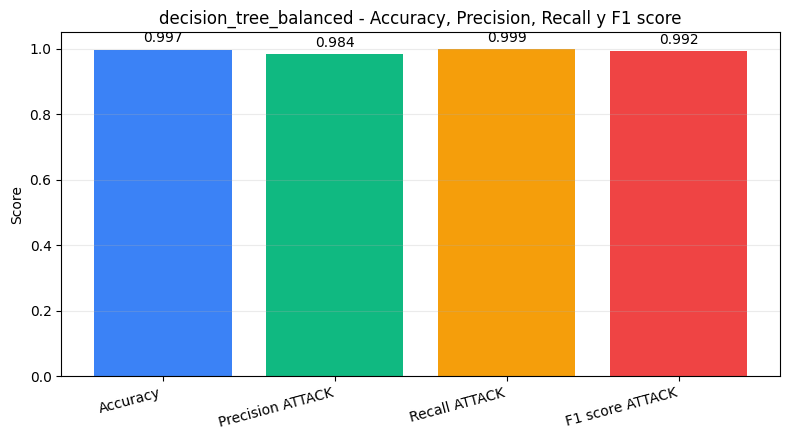

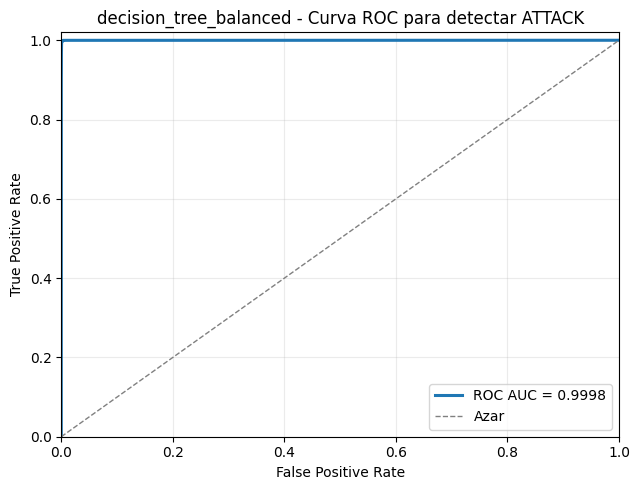


### Interpretacion - `decision_tree_balanced`

`decision_tree_balanced` pertenece a la familia **ML**. En test obtiene `accuracy = 0.9972`, `precision ATTACK = 0.9840`, `recall ATTACK = 0.9995`, `F1 ATTACK = 0.9917` y `ROC AUC = 0.9998`. En terminos practicos, registra `1,037` falsos positivos y `33` falsos negativos. Este modelo detecta intrusos con alta cobertura y pocos falsos positivos. Queda por debajo de `random_forest_balanced` en la comparacion final.


In [4]:
show_model_report('decision_tree_balanced')

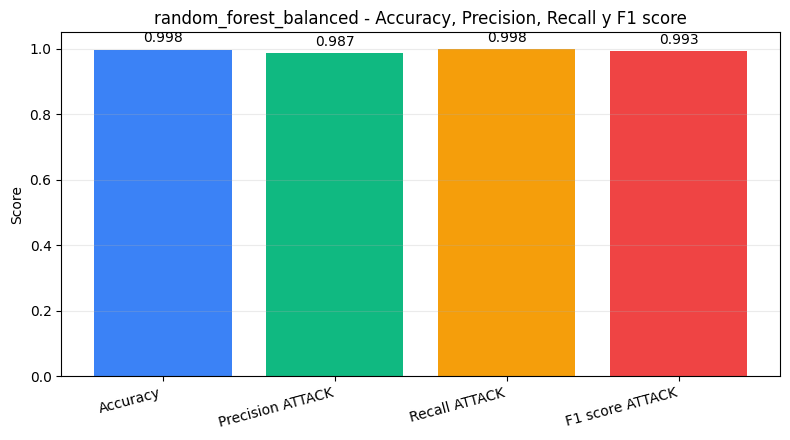

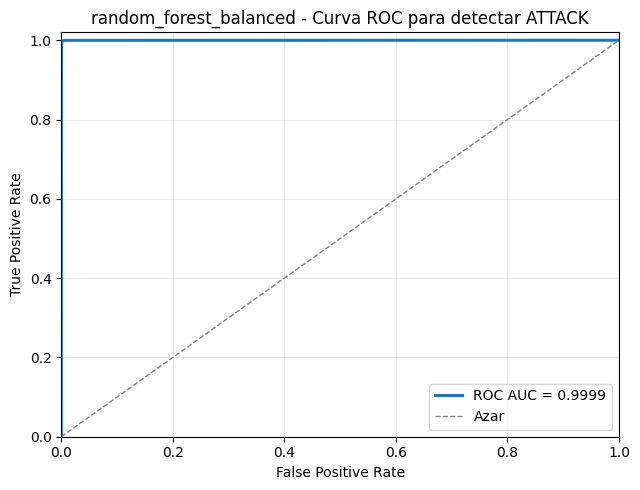


### Interpretacion - `random_forest_balanced`

`random_forest_balanced` pertenece a la familia **ML**. En test obtiene `accuracy = 0.9975`, `precision ATTACK = 0.9870`, `recall ATTACK = 0.9984`, `F1 ATTACK = 0.9927` y `ROC AUC = 0.9999`. En terminos practicos, registra `837` falsos positivos y `99` falsos negativos. Este modelo detecta intrusos con alta cobertura y pocos falsos positivos. Es el mejor modelo del test.


In [5]:
show_model_report('random_forest_balanced')

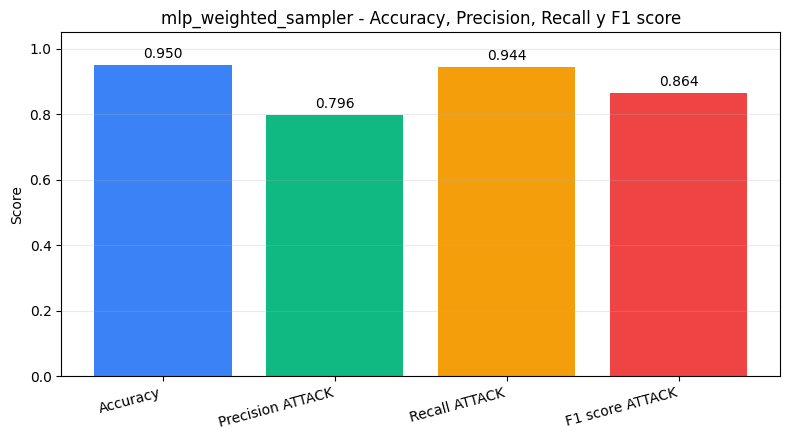

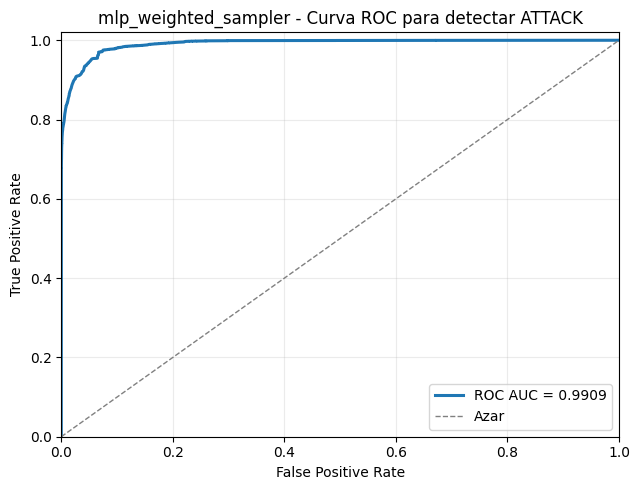


### Interpretacion - `mlp_weighted_sampler`

`mlp_weighted_sampler` pertenece a la familia **DL**. En test obtiene `accuracy = 0.9497`, `precision ATTACK = 0.7962`, `recall ATTACK = 0.9437`, `F1 ATTACK = 0.8637` y `ROC AUC = 0.9909`. En terminos practicos, registra `15,426` falsos positivos y `3,595` falsos negativos. Este modelo queda mas debil para IDS porque no combina suficientemente bien cobertura y precision sobre ATTACK. Queda por debajo de `random_forest_balanced` en la comparacion final.


In [6]:
show_model_report('mlp_weighted_sampler')

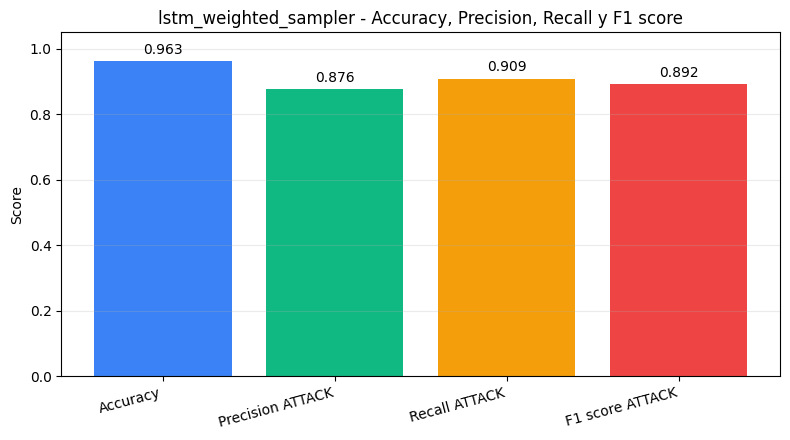

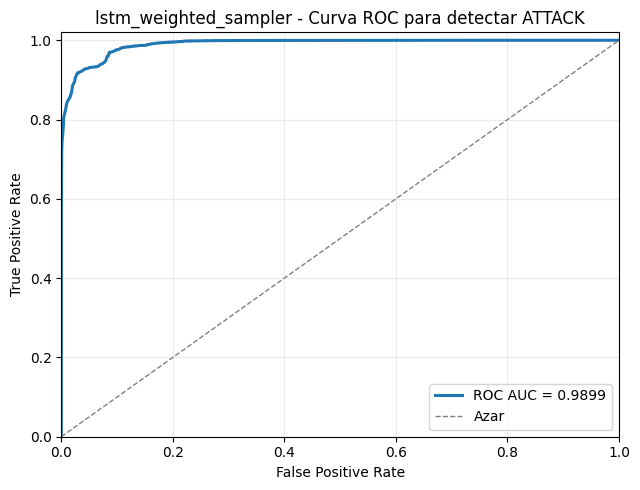


### Interpretacion - `lstm_weighted_sampler`

`lstm_weighted_sampler` pertenece a la familia **DL**. En test obtiene `accuracy = 0.9628`, `precision ATTACK = 0.8760`, `recall ATTACK = 0.9085`, `F1 ATTACK = 0.8920` y `ROC AUC = 0.9899`. En terminos practicos, registra `8,215` falsos positivos y `5,841` falsos negativos. Este modelo queda mas debil para IDS porque no combina suficientemente bien cobertura y precision sobre ATTACK. Queda por debajo de `random_forest_balanced` en la comparacion final.


In [7]:
show_model_report('lstm_weighted_sampler')

,accuracy,precision_attack,recall_attack,f1_attack,roc_auc
family,,,,,
ML,0.9973,0.9855,0.9990,0.9922,0.9999
DL,0.9563,0.8361,0.9261,0.8778,0.9904


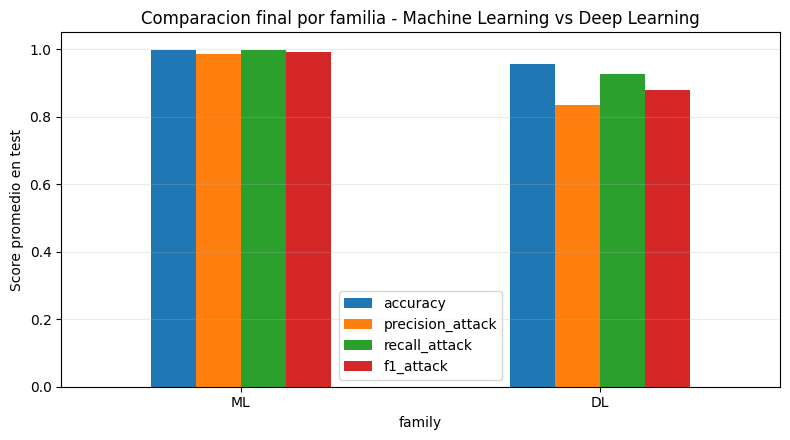


### Conclusion final - Machine Learning vs Deep Learning

Con el entrenamiento balanceado, la mejor familia promedio en test es **ML**. El mejor modelo individual es `random_forest_balanced`, con `F1 ATTACK = 0.9927`, `recall ATTACK = 0.9984` y `precision ATTACK = 0.9870`.

Para este dataset tabular de flujos CIC-IDS2017, la comparacion final debe priorizar `recall ATTACK`, `precision ATTACK`, `F1 ATTACK` y `ROC AUC`, no solo `accuracy`. Si un modelo predice demasiados benignos, puede verse bien por accuracy pero falla como detector de intrusos.


In [8]:
family_summary = (
    test_comparison
    .groupby('family')[['accuracy', 'precision_attack', 'recall_attack', 'f1_attack', 'roc_auc']]
    .mean()
    .sort_values('f1_attack', ascending=False)
)

display(family_summary.round(4))

ax = family_summary[['accuracy', 'precision_attack', 'recall_attack', 'f1_attack']].plot(
    kind='bar',
    figsize=(8, 4.5),
    ylim=(0, 1.05),
    rot=0,
)
ax.set_title('Comparacion final por familia - Machine Learning vs Deep Learning')
ax.set_ylabel('Score promedio en test')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

best_family = family_summary.index[0]
best_model_row = test_comparison.sort_values(['f1_attack', 'recall_attack', 'precision_attack'], ascending=False).iloc[0]

display(Markdown(
    f'''
### Conclusion final - Machine Learning vs Deep Learning

Con el entrenamiento balanceado, la mejor familia promedio en test es **{best_family}**. El mejor modelo individual es `{best_model_row['model']}`, con `F1 ATTACK = {best_model_row['f1_attack']:.4f}`, `recall ATTACK = {best_model_row['recall_attack']:.4f}` y `precision ATTACK = {best_model_row['precision_attack']:.4f}`.

Para este dataset tabular de flujos CIC-IDS2017, la comparacion final debe priorizar `recall ATTACK`, `precision ATTACK`, `F1 ATTACK` y `ROC AUC`, no solo `accuracy`. Si un modelo predice demasiados benignos, puede verse bien por accuracy pero falla como detector de intrusos.
'''
))
